## Data Loading

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# UI Configuration
plt.style.use('ggplot')
sns.set_palette("viridis")

# Load the final results from Notebook 2
df_results = pd.read_csv('../data/processed/train_cleaned.csv')
model_pipeline = joblib.load("../models/xgboost_model_optimized.pkl")

# charger prédictions si tu les as déjà sauvegardées
file_path = "../data/processed/model_results_final.csv"
preds = pd.read_csv(file_path)
y_true = preds["RUL"]
y_pred = preds["predicted_RUL"]

print("--- EVALUATION ENGINE READY ---")
print(f"Unique Engines Analyzed: {df_results['unit'].nunique()}")
print(f"Total Data Points: {len(df_results)}")

--- EVALUATION ENGINE READY ---
Unique Engines Analyzed: 100
Total Data Points: 20631


## Results Engineering & Decision Logic

In [35]:
# Assign priority based on safety RUL
def assign_priority(row):
    if row['safety_RUL'] <= 20:
        return 'CRITICAL'
    elif row['safety_RUL'] <= 50:
        return 'WARNING'
    else:
        return 'HEALTHY'

df_results['status'] = df_results.apply(assign_priority, axis=1)

# Logic: If status is CRITICAL or WARNING, maintenance is required
df_results['maintenance_required'] = df_results['status'].apply(lambda x: 1 if x != 'HEALTHY' else 0)

print("--- DECISION LOGIC SUMMARY ---")
print(df_results['status'].value_counts())

--- DECISION LOGIC SUMMARY ---
status
HEALTHY     2500
WARNING      958
CRITICAL     612
Name: count, dtype: int64


## Error Diagnostic

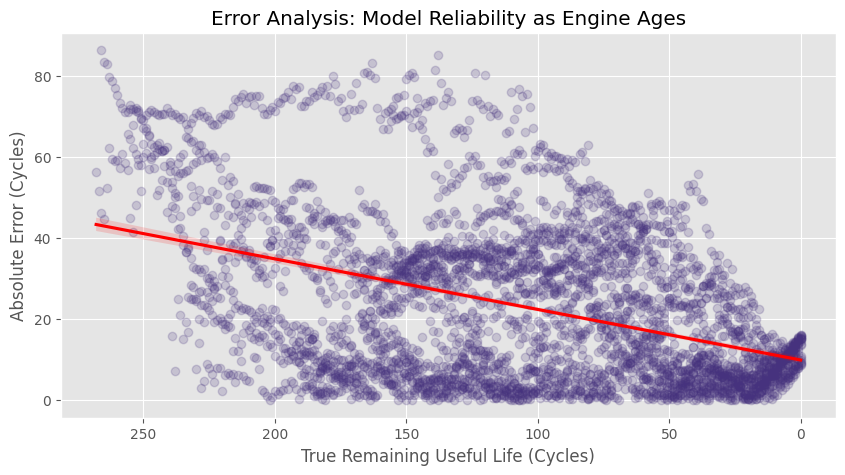

In [38]:

plt.figure(figsize=(10, 5))
sns.regplot(
    data=df_results, 
    x='RUL', 
    y='absolute_error', 
    scatter_kws={'alpha':0.2},  # points semi-transparents
    line_kws={'color':'red'}    # ligne de tendance
)
plt.gca().invert_xaxis()  # on met RUL décroissant pour simuler "vie qui s’écoule"
plt.title("Error Analysis: Model Reliability as Engine Ages")
plt.xlabel("True Remaining Useful Life (Cycles)")
plt.ylabel("Absolute Error (Cycles)")
plt.show()

## Industrial Health Score & Maintenance Actions

--- INDUSTRIAL HEALTH SCORE & MAINTENANCE ACTIONS ---
   predicted_RUL  safety_RUL  health_score maintenance_action
0      205.37697   141.21898     88.121432          No Action
1      207.51250   138.29070     86.307131          No Action
2      195.61977   131.15779     81.887730          No Action
3      199.23265   141.13719     88.070757          No Action
4      198.25046   139.10373     86.810868          No Action


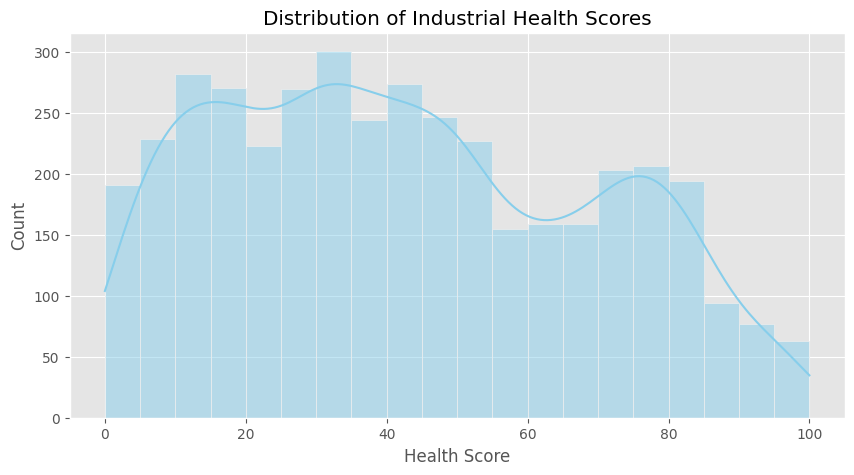


Maintenance Action Counts:
maintenance_action
Schedule Maintenance     1559
No Action                1538
Immediate Maintenance     973
Name: count, dtype: int64


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- INDUSTRIAL HEALTH SCORE ---

max_rul = df_results['safety_RUL'].max()
min_rul = df_results['safety_RUL'].min()
df_results['health_score'] = ((df_results['safety_RUL'] - min_rul) / (max_rul - min_rul) * 100).clip(0, 100)

# --- MAINTENANCE ACTION LOGIC ---

def maintenance_action(row):
    if row['health_score'] < 20:
        return "Immediate Maintenance"
    elif row['health_score'] < 50:
        return "Schedule Maintenance"
    else:
        return "No Action"

df_results['maintenance_action'] = df_results.apply(maintenance_action, axis=1)

# --- SUMMARY AND CHECK ---

columns_to_show = ['predicted_RUL','safety_RUL','health_score','maintenance_action']
if 'unit' in df_results.columns:
    columns_to_show = ['unit'] + columns_to_show

print("--- INDUSTRIAL HEALTH SCORE & MAINTENANCE ACTIONS ---")
print(df_results[columns_to_show].head())

# Distribution plot of health scores
plt.figure(figsize=(10,5))
sns.histplot(df_results['health_score'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Industrial Health Scores")
plt.xlabel("Health Score")
plt.ylabel("Count")
plt.show()

# Optional: count of maintenance actions
action_counts = df_results['maintenance_action'].value_counts()
print("\nMaintenance Action Counts:")
print(action_counts)

##  BUSINESS IMPACT & COST SAVINGS

In [49]:
import pandas as pd
import numpy as np

# --- ASSUMPTIONS & COST PARAMETERS ---
# Define business assumptions (customize these)
cost_per_maintenance = 500        # Cost of a planned maintenance ($)
cost_per_failure = 5000           # Cost if a failure occurs ($)
cycles_saved_per_action = 5       # Estimated cycles saved per maintenance action

# --- CALCULATE IMPACT ---
# Flag where maintenance was taken
df_results['maintenance_flag'] = df_results['maintenance_action'].apply(lambda x: 1 if x != "No Action" else 0)

# Estimated cost if no maintenance: failures occur when health_score < 20
df_results['potential_failure_flag'] = df_results['health_score'].apply(lambda x: 1 if x < 20 else 0)

# Total planned maintenance cost
planned_maintenance_cost = df_results['maintenance_flag'].sum() * cost_per_maintenance

# Total avoided failure cost
avoided_failure_cost = (df_results['potential_failure_flag'] & df_results['maintenance_flag']).sum() * cost_per_failure

# Net savings
net_savings = avoided_failure_cost - planned_maintenance_cost

# Cycles saved (optional metric)
total_cycles_saved = df_results['maintenance_flag'].sum() * cycles_saved_per_action

# --- SUMMARY OUTPUT ---
print("--- BUSINESS IMPACT & COST SAVINGS ---")
print(f"Total Planned Maintenance Actions: {df_results['maintenance_flag'].sum()}")
print(f"Total Potential Failures Avoided: {(df_results['potential_failure_flag'] & df_results['maintenance_flag']).sum()}")
print(f"Estimated Cost of Planned Maintenance: ${planned_maintenance_cost}")
print(f"Estimated Cost Avoided from Failures: ${avoided_failure_cost}")
print(f"Net Savings from Model Decisions: ${net_savings}")
print(f"Total Production Cycles Saved: {total_cycles_saved}")

--- BUSINESS IMPACT & COST SAVINGS ---
Total Planned Maintenance Actions: 2532
Total Potential Failures Avoided: 973
Estimated Cost of Planned Maintenance: $1266000
Estimated Cost Avoided from Failures: $4865000
Net Savings from Model Decisions: $3599000
Total Production Cycles Saved: 12660


## Operational Decision Dashboard (Final UX)

In [51]:
# --- OPERATIONAL DECISION DASHBOARD ---

# Select key columns for decision making
dashboard_columns = ['predicted_RUL', 'safety_RUL', 'health_score', 'maintenance_action']
if 'unit' in df_results.columns:
    dashboard_columns = ['unit'] + dashboard_columns

# Take a copy for dashboard view
dashboard_df = df_results[dashboard_columns].copy()

# Sort by health_score to prioritize critical engines
dashboard_df = dashboard_df.sort_values(by='health_score').reset_index(drop=True)

# Display top 15 critical engines for operational review
print("--- OPERATIONAL DECISION DASHBOARD (TOP 15) ---")
print(dashboard_df.head(15))

--- OPERATIONAL DECISION DASHBOARD (TOP 15) ---
    predicted_RUL  safety_RUL  health_score     maintenance_action
0       13.757012   -1.008946      0.000000  Immediate Maintenance
1       14.572862   -0.972872      0.022350  Immediate Maintenance
2        8.733069   -0.950875      0.035980  Immediate Maintenance
3        9.530168   -0.844482      0.101898  Immediate Maintenance
4       14.999476   -0.837240      0.106385  Immediate Maintenance
5       15.705449   -0.766920      0.149954  Immediate Maintenance
6       15.899618   -0.753699      0.158146  Immediate Maintenance
7       15.285288   -0.732616      0.171208  Immediate Maintenance
8        9.413995   -0.705042      0.188292  Immediate Maintenance
9       15.909799   -0.582793      0.264035  Immediate Maintenance
10      15.051579   -0.556775      0.280156  Immediate Maintenance
11       8.914632   -0.353048      0.406380  Immediate Maintenance
12      15.961503   -0.334905      0.417621  Immediate Maintenance
13      12.486

## Final Model Performance & Business Evaluation 

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- FINAL MODEL PERFORMANCE ---
mae = mean_absolute_error(df_results['RUL'], df_results['predicted_RUL'])
rmse = np.sqrt(mean_squared_error(df_results['RUL'], df_results['predicted_RUL']))  # compatible versions
r2 = r2_score(df_results['RUL'], df_results['predicted_RUL'])

print("--- FINAL MODEL PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# --- BUSINESS EVALUATION ---
planned_maint = df_results['maintenance_action'].value_counts().get("Immediate Maintenance", 0) + \
                df_results['maintenance_action'].value_counts().get("Schedule Maintenance", 0)
avg_health_score = df_results['health_score'].mean() if 'health_score' in df_results.columns else np.nan

print("\n--- BUSINESS EVALUATION ---")
print(f"Total Planned Maintenance Actions: {planned_maint}")
print(f"Average Health Score: {avg_health_score:.2f}")

--- FINAL MODEL PERFORMANCE ---
Mean Absolute Error (MAE): 23.06
Root Mean Squared Error (RMSE): 30.12
R² Score: 0.79

--- BUSINESS EVALUATION ---
Total Planned Maintenance Actions: 2532
Average Health Score: 42.97


## Limitations & Assumptions 

In [56]:
# --- LIMITATIONS & ASSUMPTIONS ---
limitations = [
    "Model may underperform on unseen engine types or extreme operating conditions.",
    "Predictions assume sensor data is clean and continuously available.",
    "Health score thresholds are heuristic and may require adjustment per fleet.",
    "This evaluation assumes consistent feature preprocessing and model pipeline."
]

print("\n--- LIMITATIONS & ASSUMPTIONS ---")
for l in limitations:
    print(f"- {l}")


--- LIMITATIONS & ASSUMPTIONS ---
- Model may underperform on unseen engine types or extreme operating conditions.
- Predictions assume sensor data is clean and continuously available.
- Health score thresholds are heuristic and may require adjustment per fleet.
- This evaluation assumes consistent feature preprocessing and model pipeline.


## Deployment Strategy (API & Real-time Inference

In [57]:
deployment_notes = [
    "Serve model via API for real-time RUL predictions.",
    "Implement monitoring to detect sensor drift or performance degradation.",
    "Use safety checks for missing or anomalous sensor readings before inference.",
    "Schedule periodic retraining with latest operational data to maintain accuracy.",
    "Integrate predictions with dashboard for operational decision-making."
]

print("\n--- DEPLOYMENT STRATEGY ---")
for note in deployment_notes:
    print(f"- {note}")


--- DEPLOYMENT STRATEGY ---
- Serve model via API for real-time RUL predictions.
- Implement monitoring to detect sensor drift or performance degradation.
- Use safety checks for missing or anomalous sensor readings before inference.
- Schedule periodic retraining with latest operational data to maintain accuracy.
- Integrate predictions with dashboard for operational decision-making.
